In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case)

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/10161
10161


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

In [7]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [8]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [9]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1':
    cntrl_vars_init = [1]
elif case[3] == '2':
    cntrl_vars_init = [0,1]
elif case[3] == '3':
    cntrl_vars_init = [0]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
elif case[3] == '4':
    cntrl_vars_init = [1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
elif case[3] == '5':
    cntrl_vars_init = [0,1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
elif case[3] == '6':
    cntrl_vars_init = [0]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-6) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
elif case[3] == '7':
    cntrl_vars_init = [1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-6) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
elif case[3] == '8':
    cntrl_vars_init = [0,1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-6) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
    
if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [10]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_' + case + '.pickle'
case_1 = case[0] + case[1] + '0' + case[3] + case[4]
final_file_1 = 'control_' + case_1 + '.pickle'

In [11]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [12]:
# get initial parameters and target states

i_stepsize = 5
i_range = range(0, len(exc),i_stepsize)
i_range_0 = range(0, len(exc),i_stepsize)
i_range_1 = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  5 0.4000000000000001 0.40000000000000013
-------  10 0.4250000000000001 0.42500000000000016
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 0.7000000000000004
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
-------  95 0.5250000000000001 0.750000000000000

In [13]:
# get uncontrolled cost

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  5 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.289828199723
Gradient descend method:  None
RUN  0 , total integrated cost =  5097.289828199723
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9111.456490210901
Gradient descend method:  None
RUN  0 , total integrated cost =  9111.456490210901
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  15 0.4500000000000001 0.4500000000000002

In [14]:
factor_iteration = 20.
aln.params.duration = dur

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
        
    ##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    
    if conv_init[i] == [True, True]:
    
        with open(read_file,'rb') as f:
            load_array = pickle.load(f)

        bestControl_read = load_array[0]

        bestControl_init[i] = np.zeros(( 1, 6, n_dur + n_pre + n_post -2 ))
        bestControl_init[i][:,:,n_pre-1+1000:n_pre-1+2000] = bestControl_read[i][:,:,n_pre-1:n_pre-1+1000].copy()
        weights_init = load_array[7]
        
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]   
        cost.setParams(weights_init[i][0], weights_init[i][1], weights_init[i][2])

        
        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = 0, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        continue
    
    
    if not type(bestControl_init[i]) == type(None):
        continue
        
    control0 = aln.getZeroControl()

    ##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)

    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 6664.949872655732
interpolate adjoint :  True True True


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  5840.458995629666
Gradient descend method:  None
RUN  0 , total integrated cost =  5840.458995629666
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -63.00241578387308 -63.0024107729147
-------  5 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 8115.398715917893
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5027.850879649995
Gradient descend method:  None
RUN  0 , total integrated cost =  5027.850879649995
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -68.47534716456161 -68.47534754081587
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 0.0 6063.6440777897715
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9025.400495538835
Gradient descend method:  None
RUN  0 , total integrated cost =  9025.400495538835
Improved over  0  iterations in  0.0

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  12629.452671506102
Gradient descend method:  None
RUN  0 , total integrated cost =  12629.452671506102
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -70.95764206712116 -70.95764655911897
-------  25 0.4250000000000001 0.5000000000000002
set cost params:  1.0 0.0 6461.321215758035
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8148.466443347472
Gradient descend method:  None
RUN  0 , total integrated cost =  8148.466443347472
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -75.18538652523092 -75.18539185158903
-------  30 0.4250000000000001 0.5250000000000002
set cost params:  1.0 0.0 6603.613964010899
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7910.090642057416
Gradient descend method:  None
RUN  0 , total integrated cost =  7910.090642057416
Improved over  0  iterations in  0.

...

RUN  0 , total integrated cost =  35596.36999810652
Gradient descend method:  None
RUN  0 , total integrated cost =  35596.36999810652
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  80 0.5250000000000001 0.7000000000000004
set cost params:  1.0 0.0 6250.754390023022
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  48520.09771744724
Gradient descend method:  None
RUN  0 , total integrated cost =  48520.09771744724
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  85 0.47500000000000014 0.7250000000000004
set cost params:  1.0 0.0 5991.666994621064
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15007.427567883893
Gradient descend method:  None
RUN  0 , total integrated cost =  15007.427567883893
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -77.09474459553462 -77.0947577795813
-------  90 0.6000000000000003 0.7250000000000004
set 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params:  1.0 0.0 8735.691710398934
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  34809.98149796574
Gradient descend method:  None
RUN  0 , total integrated cost =  34809.98149796574
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  110 0.5000000000000002 0.8000000000000005
set cost params:  1.0 0.0 6070.598523358603
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38228.84356917168
Gradient descend method:  None
RUN  0 , total integrated cost =  38228.84356917168
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  115 0.4250000000000001 0.8250000000000005
set cost params:  1.0 0.0 8510.38584507861
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5774.359877420163
Gradient descend method:  None
RUN  0 , total integrated cost =  5774.359877420163
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -83.2398049

ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  39872.36780236251
Gradient descend method:  None
RUN  0 , total integrated cost =  39872.36780236251
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  135 0.5250000000000001 0.8750000000000006
set cost params:  1.0 0.0 6265.385361720776
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  46695.27083910399
Gradient descend method:  None
RUN  0 , total integrated cost =  46695.27083910399
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 6373.258915701614
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9919.09633447486
Gradient descend method:  None
RUN  0 , total integrated cost =  9919.09633447486
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -81.33675384120964 -81.33676414006874
-------  145 0.5750000000000002 0.9000000000000006
set c

--------- 0
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


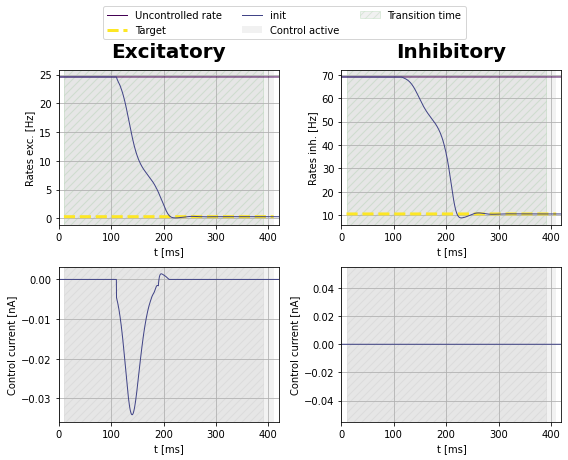

--------- 5
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


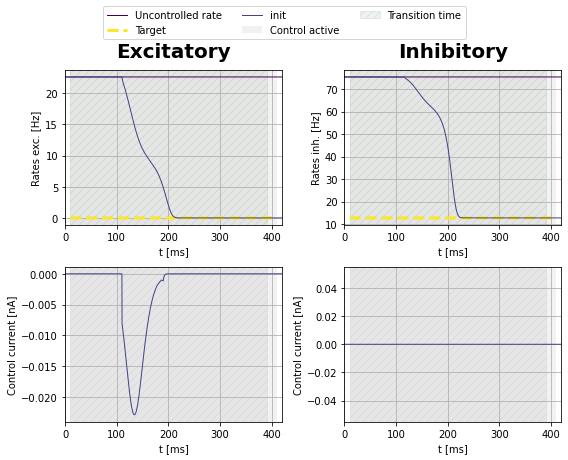

--------- 10
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


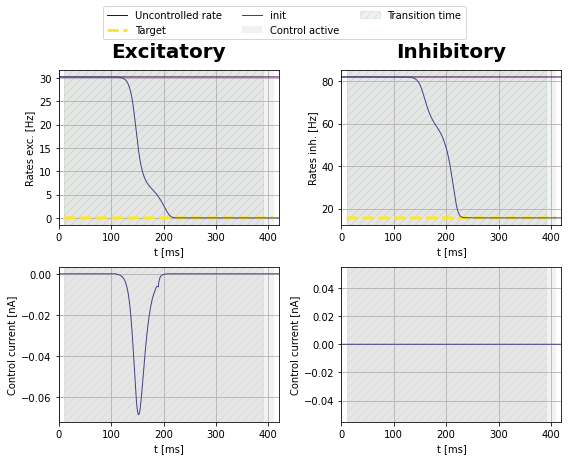

--------- 15
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


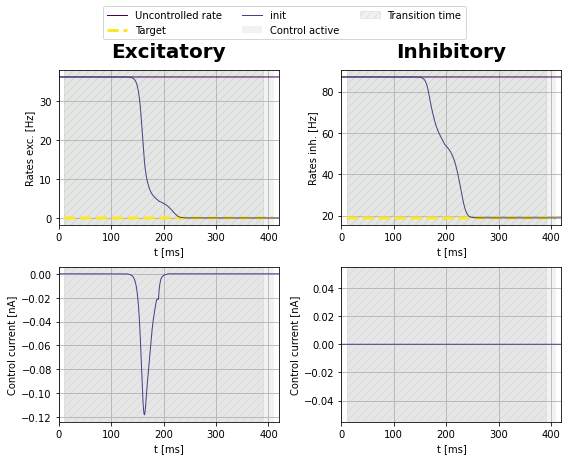

--------- 20
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


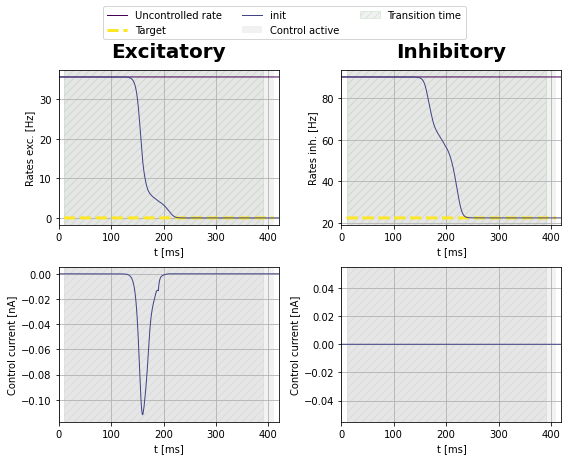

--------- 25
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


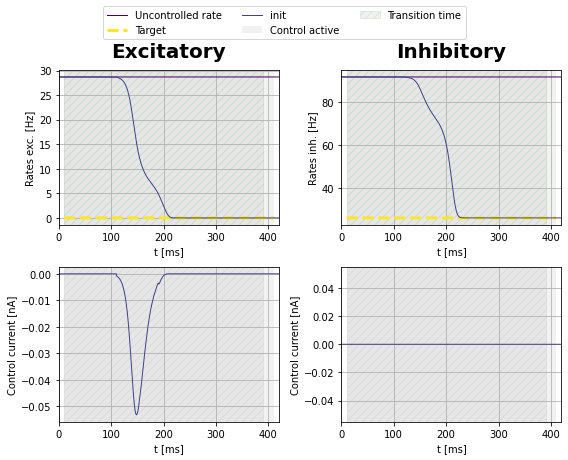

--------- 30
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


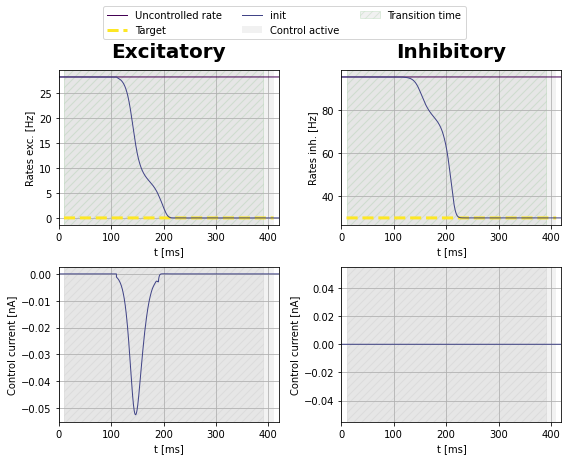

--------- 35
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


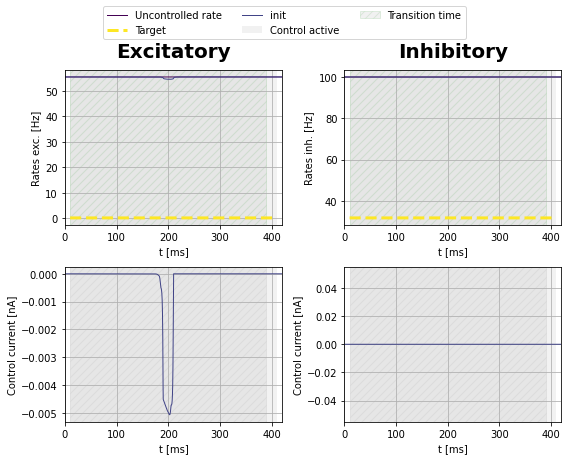

--------- 40
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


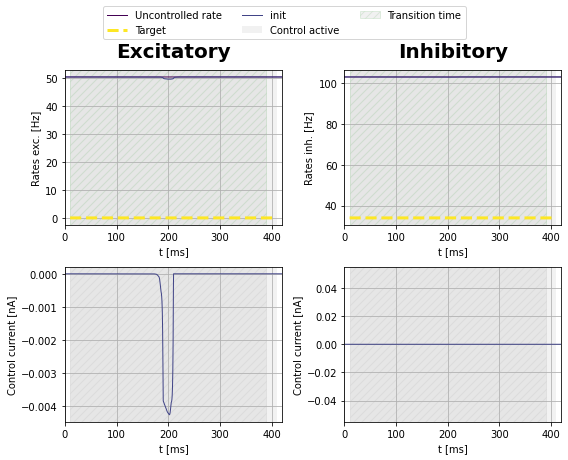

--------- 45
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


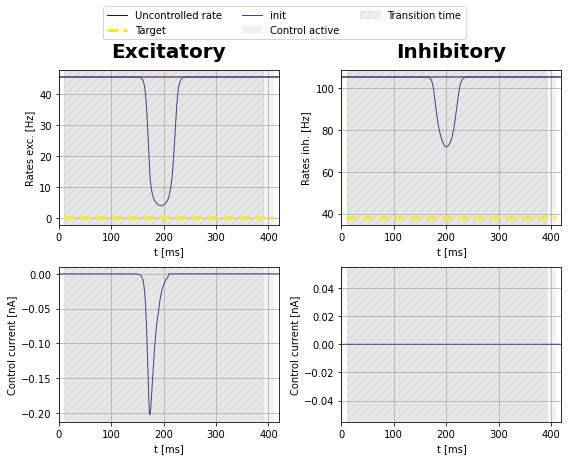

--------- 50
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


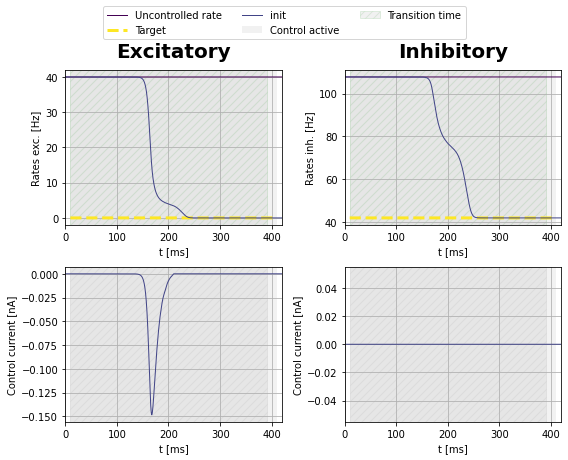

--------- 55
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


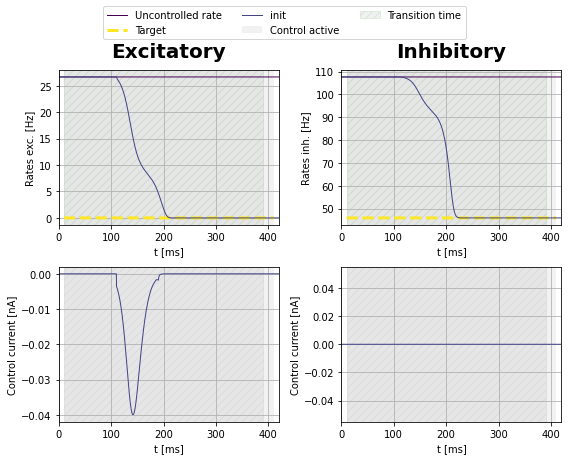

--------- 60
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


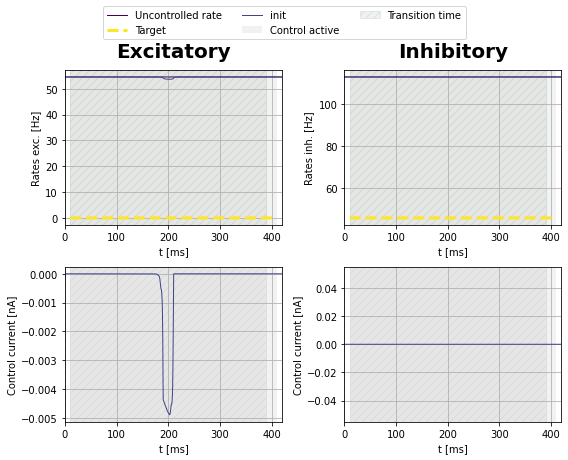

--------- 65
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


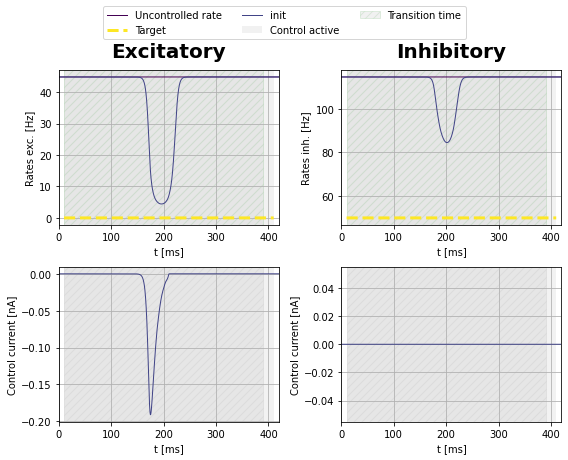

--------- 70
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


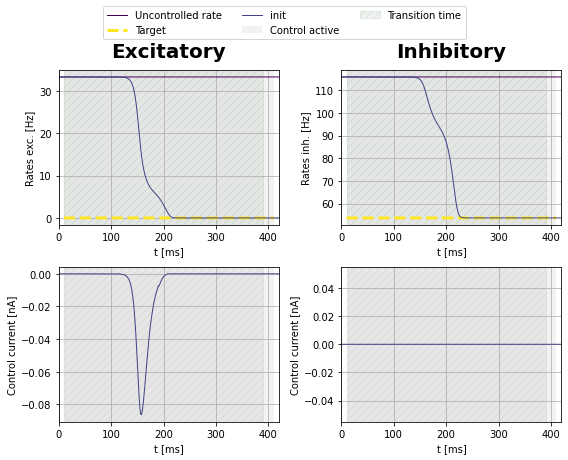

--------- 75
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


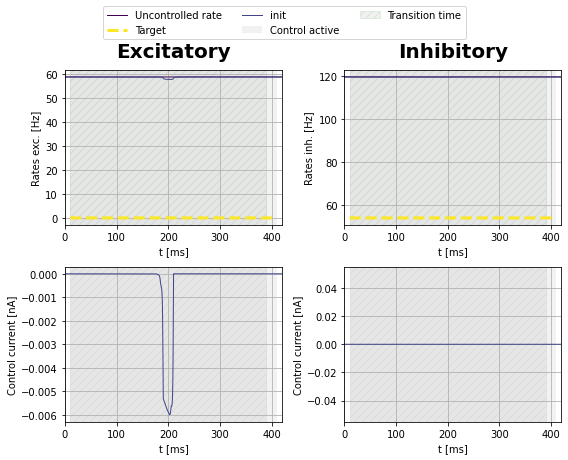

--------- 80
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


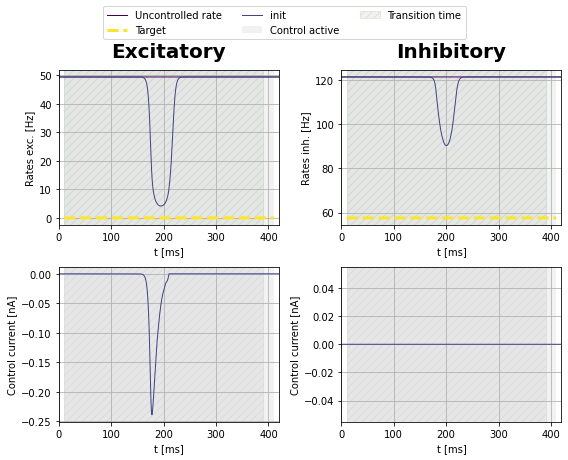

--------- 85
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


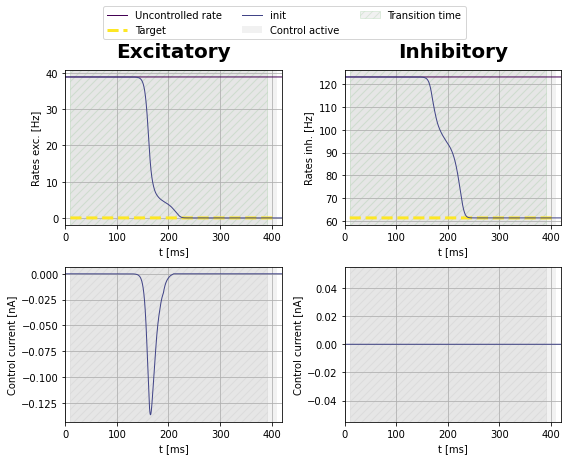

--------- 90
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


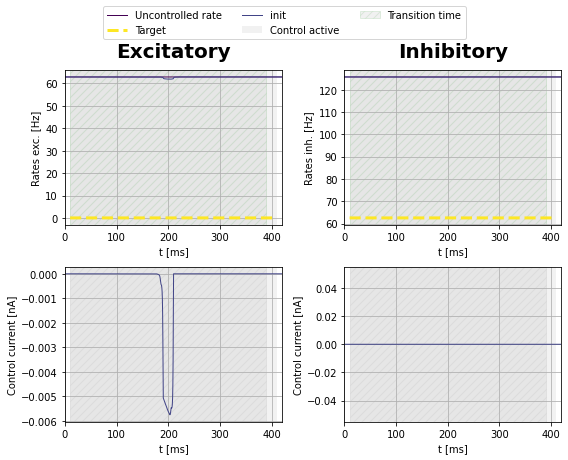

--------- 95
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


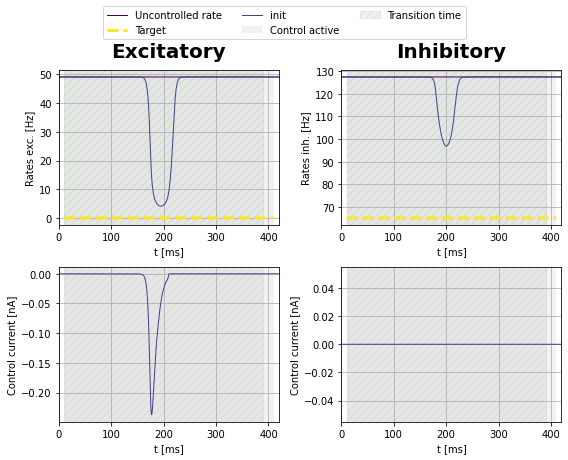

--------- 100
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


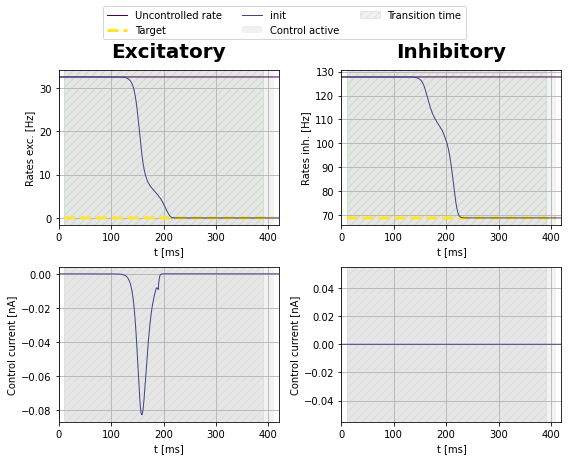

--------- 105
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


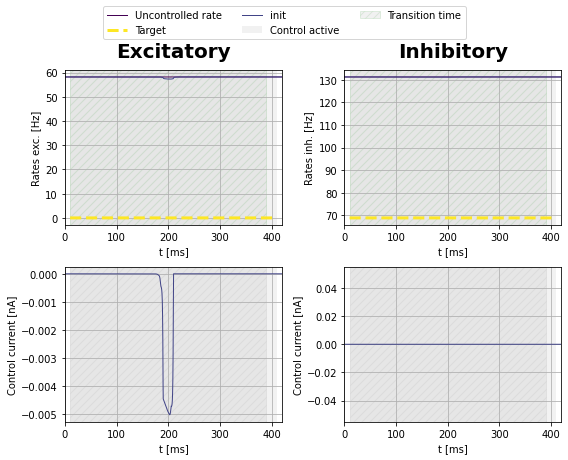

--------- 110
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


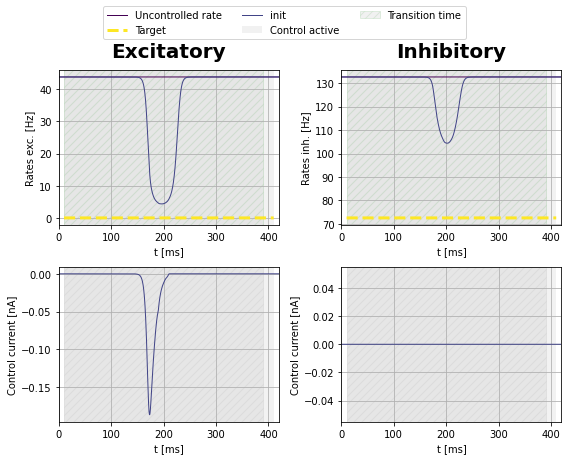

--------- 115
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


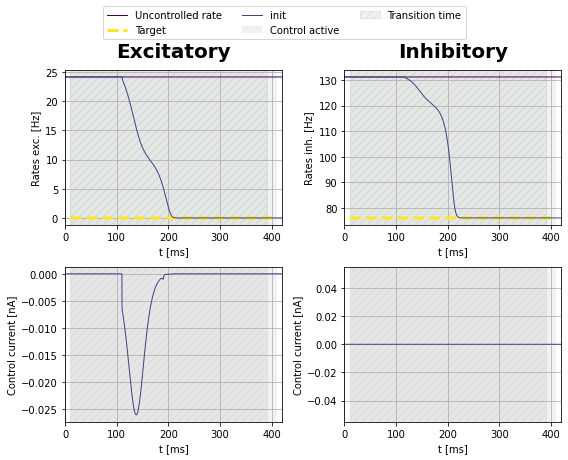

--------- 120
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


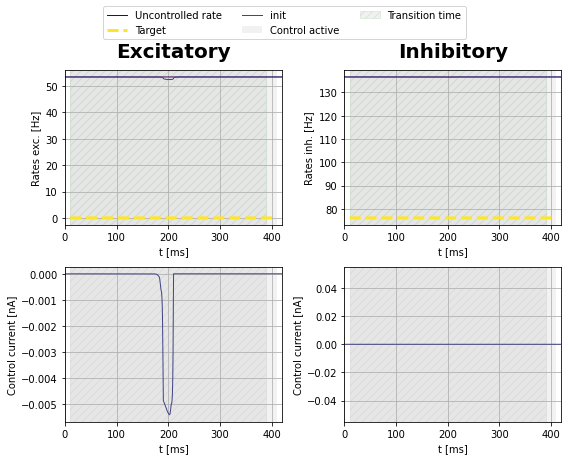

--------- 125
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


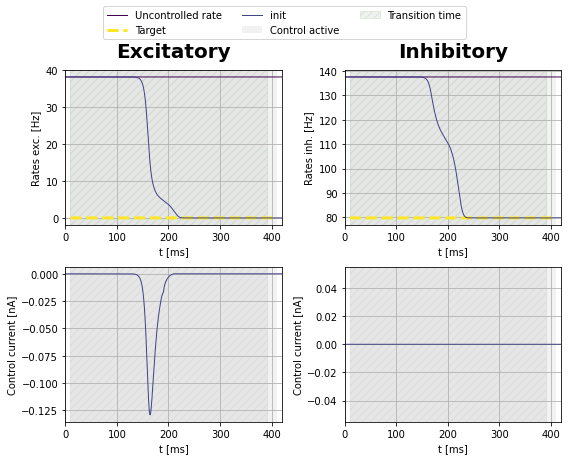

--------- 130
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


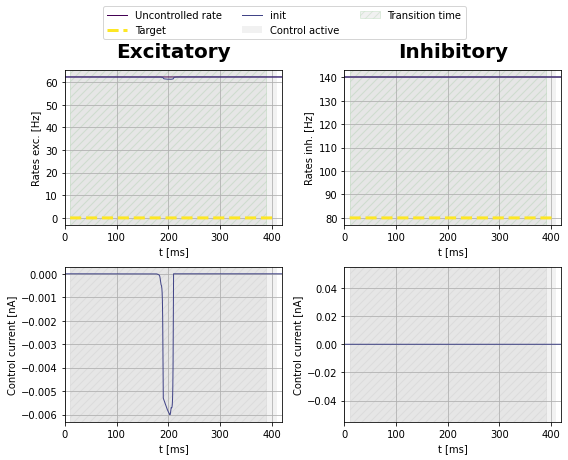

--------- 135
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


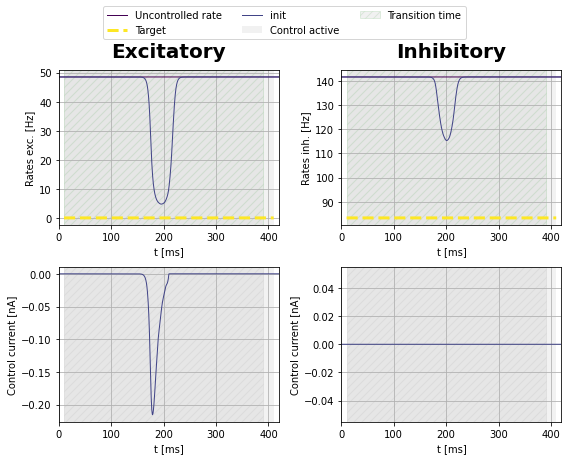

--------- 140
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


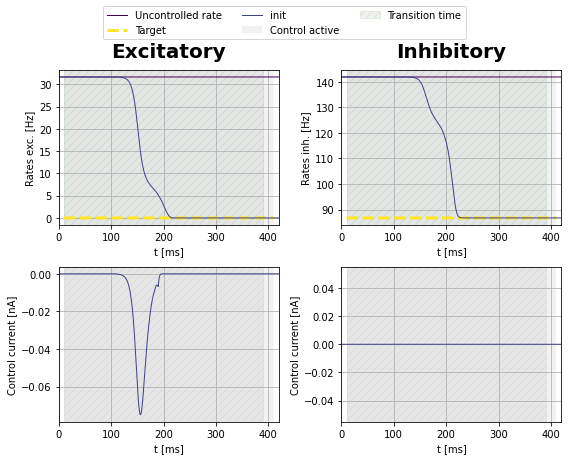

--------- 145
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


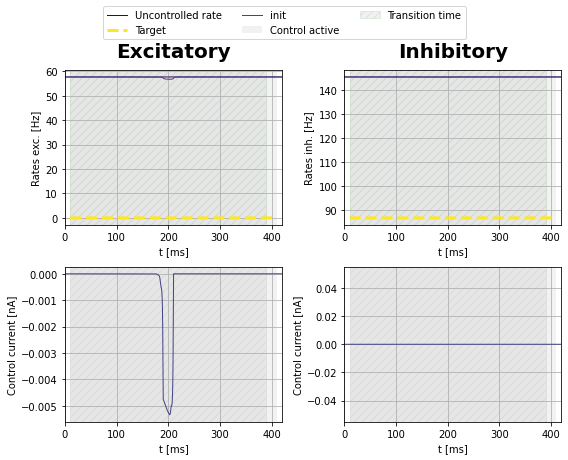

In [15]:

#plot initial guesses
for i in i_range:
    print("---------", i)
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()


In [16]:
found_solution = []
no_solution = []
factor_iteration = 1
already_tried = [ [] for _ in range(len(exc)) ]
factor_control = 1.

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])    

        if np.abs(np.mean(bestState_init[i][0,0,-300:]) - target[i][0,0,-1]) < 0.1 * np.abs(
                np.mean(bestState_init[i][0,0,-100:]) - bestState_init[i][0,0,0]) and np.abs(
                np.mean(bestState_init[i][0,1,-100:]) - target[i][0,1,-1]) < 0.5 * np.abs(
                np.mean(bestState_init[i][0,1,-100:]) - bestState_init[i][0,1,0]) and np.amin(
                bestState_init[i][0,0,:]) > target[i][0,0,-1] - 5. and np.amin(
                bestState_init[i][0,1,:]) > target[i][0,1,-1] - 5.:
            # and np.amin(bestState_init[i][0,0,:]) > bestState_init[i][0,0,0] - 1.
            #and np.amin(bestState_init[i][0,1,:]) > bestState_init[i][0,1,0] - 1.:
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue
            
        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = factor_control * bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue
                
        max_it = 0
                
        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
                
        if cost_init[i][-1] > 0.2 * cost_uncontrolled[i]:
            print("closest index was not successful")
            continue

        weight_ = 10. * cost_uncontrolled[i] / cost_init[i][-1]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(2)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                         costnode_init, weights_init], f)
            
    factor_control += 0.1
        

------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  5 0.4000000000000001 0.40000000000000013
found solution for  5
-------  10 0.4250000000000001 0.42500000000000016
found solution for  10
-------  15 0.4500000000000001 0.4500000000000002
found solution for  15
-------  20 0.4500000000000001 0.4750000000000002
found solution for  20
-------  25 0.4250000000000001 0.5000000000000002
found solution for  25
-------  30 0.4250000000000001 0.5250000000000002
found solution for  30
-------  35 0.5500000000000003 0.5250000000000002
[0, 5, 10, 15, 20, 25, 30] []
closest index  20
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30568.065753773608
Gradient descend method:  None
RUN  0 , total integrated cost =  30568.065753773608
Improved over  0  iterations in  0.0  seco

RUN  0 , total integrated cost =  24444.4181342865
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
closest index was not successful
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
[0, 5, 10, 15, 20, 25, 30, 50, 55, 70, 85, 100, 115, 125, 140] [85]
closest index  70
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  39360.57596442897
Gradient descend method:  None
RUN  0 , total integrated cost =  39360.57596442897
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
closest index was not successful
-------  95 0.5250000000000001 0.7500000000000004
[0, 5, 10, 15, 20, 25, 30, 50, 55, 70, 85, 100, 115, 125, 140] [85]
closest index  100
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24146.880226915437
Gradient descend method:  None
RUN  0 , total integrated cost =  24146.880226915437
Improved over  0  ite

RUN  0 , total integrated cost =  30562.000939065354
Gradient descend method:  None
RUN  0 , total integrated cost =  30562.000939065354
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
closest index was not successful
-------  40 0.5250000000000001 0.5500000000000003
[0, 5, 10, 15, 20, 25, 30, 50, 55, 70, 85, 100, 115, 125, 140] [30, 50, 20]
closest index  25
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  25547.872195137392
Gradient descend method:  None
RUN  0 , total integrated cost =  25547.872195137392
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
closest index was not successful
-------  45 0.5000000000000002 0.5750000000000003
[0, 5, 10, 15, 20, 25, 30, 50, 55, 70, 85, 100, 115, 125, 140] [30, 50, 55]
closest index  25
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20644.302383764592
Gradient descend method:  None
RUN  0 , total integra

RUN  0 , total integrated cost =  20658.199371470037
Gradient descend method:  None
RUN  0 , total integrated cost =  20658.199371470037
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
closest index was not successful
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
[0, 5, 10, 15, 20, 25, 30, 50, 55, 70, 85, 100, 115, 125, 140] [50, 70, 85, 55]
closest index  30
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  29812.40964287555
Gradient descend method:  None
RUN  0 , total integrated cost =  29812.40964287555
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
closest index was not successful
-------  65 0.5000000000000002 0.6500000000000004
[0, 5, 10, 15, 20, 25, 30, 50, 55, 70, 85, 100, 115, 125, 140] [50, 70, 85, 55]
closest index  100
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True Tru

ERROR:root:Problem in initial value trasfer


...

RUN  2 , total integrated cost =  24648.57559723524
RUN  2 , total integrated cost =  24648.57559723524
Improved over  2  iterations in  0.5654379539191723  seconds by  19.307830309967215  percent.
Problem in initial value trasfer:  Vmean_exc -62.44104651895002 -62.443079482026654


ERROR:root:Problem in initial value trasfer


-------  40 0.5250000000000001 0.5500000000000003
[0, 5, 10, 15, 20, 25, 30, 50, 55, 70, 85, 100, 115, 125, 140, 95, 45, 105, 110, 120, 130, 135, 145] [30, 50, 20, 25, 55, 15, 70, 10]
closest index  45
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  61.7816715176191
Gradient descend method:  None
RUN  0 , total integrated cost =  61.7816715176191
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -67.74221478662173 -67.74221392090581
weight =  4132.532687823353
set cost params:  1.0 0.0 4132.532687823353
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  25531.47770548847
Gradient descend method:  None
RUN  1 , total integrated cost =  17713.869177689154


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  17355.56212016553
RUN  2 , total integrated cost =  17355.56212016553
Improved over  2  iterations in  0.596116816624999  seconds by  32.022884376823086  percent.
Problem in initial value trasfer:  Vmean_exc -67.7407220677043 -67.74072826316106
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
found solution for  60
-------  65 0.5000000000000002 0.6500000000000004
found solution for  65
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
found solution for  75
-------  80 0.5250000000000001 0.7000000000000004
found solution for  80
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
found solution for  90
-------  95 0.5250000000000001 0.7500000000000004
-------  100 0.4500000000000001 0.7750000000000005
---

In [17]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [ ]:
factor_iteration = 20
conv_0 = [[False]*2] * len(exc)
full_converge = False

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 20:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break
        
    counter += 1
    
    for i in i_range_0:
        print("------- ", i, exc[i], inh[i])
        
        if conv_0[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

    # exc and inh control current 

        setinit(initVars[i], aln)
        aln.params.duration = dur
        
        for i in [35, 40, 45, 75, 80, 90, 105, 120, 130, 145]:
            bestControl_0[i] = None

        if not type(bestControl_0[i]) == type(None):
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
        else:
            control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
            weights_0[i] = weights_init[i]
            cost_0[i] = cost_init[i]

        cgv = None
        max_it = 500 * factor_iteration

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                           + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        with open(final_file,'wb') as f:
            pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                     costnode_0, weights_0], f)
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  6484.5873340051985
set cost params:  1.0 0.0 6484.5873340051985
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33285.77747605517
Gradient descend method:  None
RUN  1 , total integrated cost =  7235.37812725398
RUN  2 , total integrated cost =  6115.686013012281
RUN  3 , total integrated cost =  6101.75745697038
RUN  4 , total integrated cost =  6091.68445007636
RUN  5 , total integrated cost =  6083.436439428549


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  345 , total integrated cost =  3752.8736551866637
Improved over  345  iterations in  322.5627473909408  seconds by  88.72500275448107  percent.
Problem in initial value trasfer:  Vmean_exc -67.8868541678613 -67.88993236393134
no convergence
-------  10 0.4250000000000001 0.42500000000000016
weight =  6484.5873340051985
set cost params:  1.0 0.0 6484.5873340051985
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33284.91854921068
Gradient descend method:  None
RUN  1 , total integrated cost =  9191.912691053714
RUN  2 , total integrated cost =  9112.739934650079
RUN  3 , total integrated cost =  9112.583997962522
RUN  4 , total integrated cost =  9112.483886739856
RUN  5 , total integrated cost =  9112.336990679289
RUN  6 , total integrated cost =  9112.264942162268
RUN  7 , total integrated cost =  9112.205633208265
RUN  8 , total integrated cost =  9112.175297713731
RUN  9 , total integrated cost =  9112.077685752003
RUN  10

ERROR:root:Problem in initial value trasfer


RUN  10000 , total integrated cost =  14361.572729724308
RUN  10000 , total integrated cost =  14361.572729724308
Improved over  10000  iterations in  7564.661170663312  seconds by  56.852612660809825  percent.
Problem in initial value trasfer:  Vmean_exc -68.25080616388377 -68.25378940132182
no convergence
-------  20 0.4500000000000001 0.4750000000000002
weight =  6484.5873340051985
set cost params:  1.0 0.0 6484.5873340051985
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33284.91854782574
Gradient descend method:  None
RUN  1 , total integrated cost =  12817.297987951471
RUN  2 , total integrated cost =  12733.265660479707
RUN  3 , total integrated cost =  12703.275033475573
RUN  4 , total integrated cost =  12676.078320531491
RUN  5 , total integrated cost =  12676.078320531486
RUN  6 , total integrated cost =  12676.07832053148


...

RUN  4 , total integrated cost =  10017.584861024925
Control only changes marginally.
RUN  4 , total integrated cost =  10017.584861024925
Improved over  4  iterations in  4.63405723311007  seconds by  69.90353199954266  percent.
Problem in initial value trasfer:  Vmean_exc -56.651268671006726 -56.651279325828476
no convergence
-------  145 0.5750000000000002 0.9000000000000006
weight =  6484.5873340051985
set cost params:  1.0 0.0 6484.5873340051985
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33284.91853908665
Gradient descend method:  None
RUN  1 , total integrated cost =  33276.77284397021
RUN  2 , total integrated cost =  33276.342064485456
RUN  3 , total integrated cost =  33276.33265431967
RUN  4 , total integrated cost =  33276.33263540496
RUN  5 , total integrated cost =  33276.33262966601
RUN  6 , total integrated cost =  33276.33262220367
RUN  7 , total integrated cost =  33276.332617380096
RUN  8 , total integrated cost =  33276.33260866204
RUN  9

ERROR:root:Problem in initial value trasfer


RUN  10000 , total integrated cost =  32939.773176535986
RUN  10000 , total integrated cost =  32939.773176535986
Improved over  10000  iterations in  9125.098212249577  seconds by  1.036942187932226  percent.
Problem in initial value trasfer:  Vmean_exc -67.82928040864559 -67.83395759029955
no convergence
--------------- 1
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  6484.5873340051985
set cost params:  1.0 0.0 6484.5873340051985
interpolate adjoint :  True True True
RUN  0 , total integrated cost =

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  345 , total integrated cost =  3752.8736551866637
Improved over  345  iterations in  317.6073456071317  seconds by  88.72500275448107  percent.
Problem in initial value trasfer:  Vmean_exc -67.8868541678613 -67.88993236393134
no convergence
-------  10 0.4250000000000001 0.42500000000000016
weight =  6484.5873340051985
set cost params:  1.0 0.0 6484.5873340051985
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33284.91854921068
Gradient descend method:  None
RUN  1 , total integrated cost =  9191.912691053714
RUN  2 , total integrated cost =  9112.739934650079
RUN  3 , total integrated cost =  9112.583997962522
RUN  4 , total integrated cost =  9112.483886739856
RUN  5 , total integrated cost =  9112.336990679289
RUN  6 , total integrated cost =  9112.264942162268
RUN  7 , total integrated cost =  9112.205633208265
RUN  8 , total integrated cost =  9112.175297713731
RUN  9 , total integrated cost =  9112.077685752003
RUN  10

In [ ]:

for i in i_range_0:
    
    print(i)
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()


In [ ]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [ ]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    if counter > 20:
        break
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_1[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        if not type(bestControl_1[i]) == type(None):
            control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1].copy()
        else:
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1].copy()
            cost_1[i] = cost_0[i]
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(final_file_1,'wb') as f:
            pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)
            
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
    counter += 1